# Laboratorio 6 – K Nearest Neighbors (KNN)


In [1]:
import sys
print(sys.executable)

/Users/anggiequezada/Desktop/septimo semestre/Minsería/lab5-md/Lab5-md/nombre_entorno/bin/python


In [2]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scipy pyreadr scikit-learn

zsh:1: no such file or directory: /Users/anggiequezada/Desktop/septimo


In [3]:
# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [4]:
# Cargar conjuntos de datos
X_train = pd.read_csv('data/X_train.csv')
X_test  = pd.read_csv('data/X_test.csv')
y_train = pd.read_csv('data/y_train.csv').squeeze()  # precio (numérico)
y_test  = pd.read_csv('data/y_test.csv').squeeze()

# Cargar dataset con categoría de precio (barata, media, cara)
df_cat = pd.read_csv('data/df_con_categoria.csv')

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')
print(f'\nColumnas en X_train:')
print(X_train.columns.tolist())

X_train: (52871, 20) | X_test: (22660, 20)
y_train: (52871,) | y_test: (22660,)

Columnas en X_train:
['room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable']


In [5]:
print(df_cat.columns.tolist())

['price', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'maximum_nights', 'number_of_reviews', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count', 'host_is_superhost', 'neighbourhood_cleansed', 'instant_bookable', 'precio_categoria']


In [6]:
# Extraer variable categórica de precio para clasificación
# Ajustar el nombre de la columna según el CSV real
col_categoria = 'precio_categoria'

y_train_cat = df_cat.loc[X_train.index, col_categoria]
y_test_cat  = df_cat.loc[X_test.index, col_categoria]

print('Distribución de categorías (train):')
print(y_train_cat.value_counts())

Distribución de categorías (train):
precio_categoria
Intermedia    27033
Cara          13508
Economica     12330
Name: count, dtype: int64


### 3. Preprocesamiento: Escalado de features

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Escalado aplicado correctamente.')
print(f'Media aproximada post-escalado (train): {X_train_scaled.mean():.4f}')

Escalado aplicado correctamente.
Media aproximada post-escalado (train): -0.0000


### Punto 1 – Modelo KNN para Regresión (predicción de precio)

In [8]:
start_time = time.time()

knn_reg = KNeighborsRegressor(n_neighbors=5, metric='minkowski', p=2)  # p=2 → distancia Euclidiana
knn_reg.fit(X_train_scaled, y_train)

y_pred_reg = knn_reg.predict(X_test_scaled)

tiempo_reg = time.time() - start_time
print(f'Modelo entrenado y predicciones generadas en {tiempo_reg:.3f} segundos.')

Modelo entrenado y predicciones generadas en 0.419 segundos.


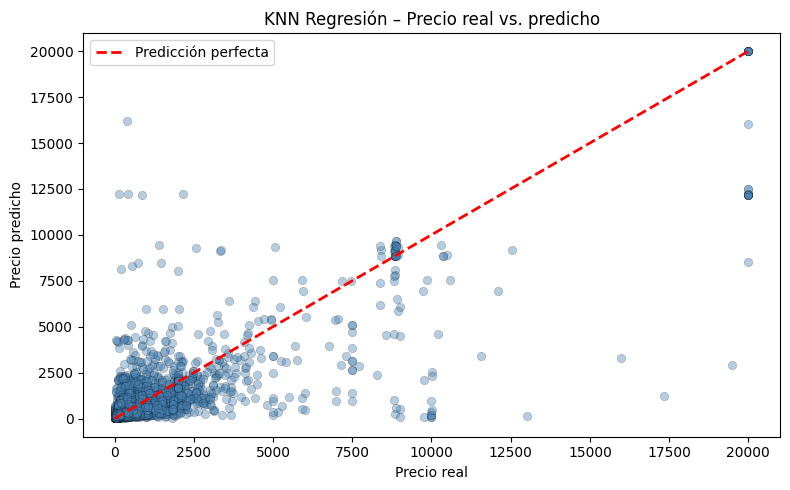

In [9]:
# Visualización: predicciones vs valores reales
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_reg, alpha=0.4, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('KNN Regresión – Precio real vs. predicho')
plt.legend()
plt.tight_layout()
plt.show()

### Punto 2 – Análisis de métricas del modelo de regresión

In [10]:
mae_reg  = mean_absolute_error(y_test, y_pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test, y_pred_reg))
r2_reg   = r2_score(y_test, y_pred_reg)

print(' Métricas KNN Regresión (k=5) ')
print(f'  MAE  : {mae_reg:.4f}')
print(f'  RMSE : {rmse_reg:.4f}')
print(f'  R²   : {r2_reg:.4f}')
print(f'  Tiempo: {tiempo_reg:.3f} s')

 Métricas KNN Regresión (k=5) 
  MAE  : 156.0668
  RMSE : 556.2815
  R²   : 0.6340
  Tiempo: 0.419 s


#### Interpretación
> Completar después de ver los valores reales
> Analizar si el MAE/RMSE es aceptable en relación al rango de precios del dataset.  
> Un R² > 0.7 indicaría un modelo con capacidad predictiva razonable.  
> Si el R² es bajo, KNN podría estar teniendo dificultades con la alta dimensionalidad o la variabilidad del precio.

### Punto 3 – Comparación de modelos de regresión

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import time

print('Imports del punto 3 cargados.')

Imports del punto 3 cargados.


In [13]:
# ── Regresión Lineal ──────────────────────────────────────────────────────────
t0 = time.time()
rl = LinearRegression()
rl.fit(X_train_scaled, y_train)
y_pred_rl = rl.predict(X_test_scaled)
tiempo_rl = time.time() - t0

mae_rl  = mean_absolute_error(y_test, y_pred_rl)
rmse_rl = np.sqrt(mean_squared_error(y_test, y_pred_rl))
r2_rl   = r2_score(y_test, y_pred_rl)

print(f'Regresión Lineal  →  MAE={mae_rl:.2f}  RMSE={rmse_rl:.2f}  R²={r2_rl:.4f}  t={tiempo_rl:.3f}s')

# ── Árbol de Regresión (profundidad 7, el mejor de Lab 4) ─────────────────────
t0 = time.time()
arbol = DecisionTreeRegressor(max_depth=7, random_state=42)
arbol.fit(X_train, y_train)          # El árbol NO necesita escalar
y_pred_arbol = arbol.predict(X_test)
tiempo_arbol = time.time() - t0

mae_arbol  = mean_absolute_error(y_test, y_pred_arbol)
rmse_arbol = np.sqrt(mean_squared_error(y_test, y_pred_arbol))
r2_arbol   = r2_score(y_test, y_pred_arbol)

print(f'Árbol Regresión   →  MAE={mae_arbol:.2f}  RMSE={rmse_arbol:.2f}  R²={r2_arbol:.4f}  t={tiempo_arbol:.3f}s')

# ── Naive Bayes (Lab 5) – cargamos resultados ya calculados ──────────────────
# Si los valores de NB están disponibles como variables, úsalos directamente.
# Si no, puedes ingresarlos manualmente desde el notebook del Lab 5.
# Ejemplo (reemplaza con tus valores reales):
mae_nb_reg  = None   # ← reemplaza con el valor de tu Lab 5
rmse_nb_reg = None   # ← reemplaza con el valor de tu Lab 5
r2_nb_reg   = None   # ← reemplaza con el valor de tu Lab 5

print('\nModelos re-entrenados correctamente.')

Regresión Lineal  →  MAE=257.02  RMSE=839.74  R²=0.1660  t=0.032s
Árbol Regresión   →  MAE=166.01  RMSE=502.91  R²=0.7009  t=0.115s

Modelos re-entrenados correctamente.


In [14]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
import pandas as pd

comparacion_reg = pd.DataFrame([
    {'Modelo': 'KNN Regresión (k=5)',    'MAE': mae_reg,    'RMSE': rmse_reg,    'R²': r2_reg,    'Tiempo (s)': tiempo_reg},
    {'Modelo': 'Regresión Lineal',       'MAE': mae_rl,     'RMSE': rmse_rl,     'R²': r2_rl,     'Tiempo (s)': tiempo_rl},
    {'Modelo': 'Árbol Regresión (d=7)',  'MAE': mae_arbol,  'RMSE': rmse_arbol,  'R²': r2_arbol,  'Tiempo (s)': tiempo_arbol},
])

# Agrega Naive Bayes solo si tienes los valores
if mae_nb_reg is not None:
    fila_nb = pd.DataFrame([{'Modelo': 'Naive Bayes (Lab 5)', 'MAE': mae_nb_reg, 'RMSE': rmse_nb_reg, 'R²': r2_nb_reg, 'Tiempo (s)': None}])
    comparacion_reg = pd.concat([comparacion_reg, fila_nb], ignore_index=True)

comparacion_reg = comparacion_reg.sort_values('RMSE').reset_index(drop=True)

print('COMPARACIÓN – MODELOS DE REGRESIÓN (menor RMSE = mejor)')
print(comparacion_reg.to_string(index=False))
print(f"\nMejor modelo: {comparacion_reg.iloc[0]['Modelo']}")

COMPARACIÓN – MODELOS DE REGRESIÓN (menor RMSE = mejor)
               Modelo        MAE       RMSE       R²  Tiempo (s)
Árbol Regresión (d=7) 166.006131 502.909568 0.700874    0.114665
  KNN Regresión (k=5) 156.066752 556.281505 0.634015    0.419228
     Regresión Lineal 257.021386 839.736731 0.166010    0.031877

Mejor modelo: Árbol Regresión (d=7)


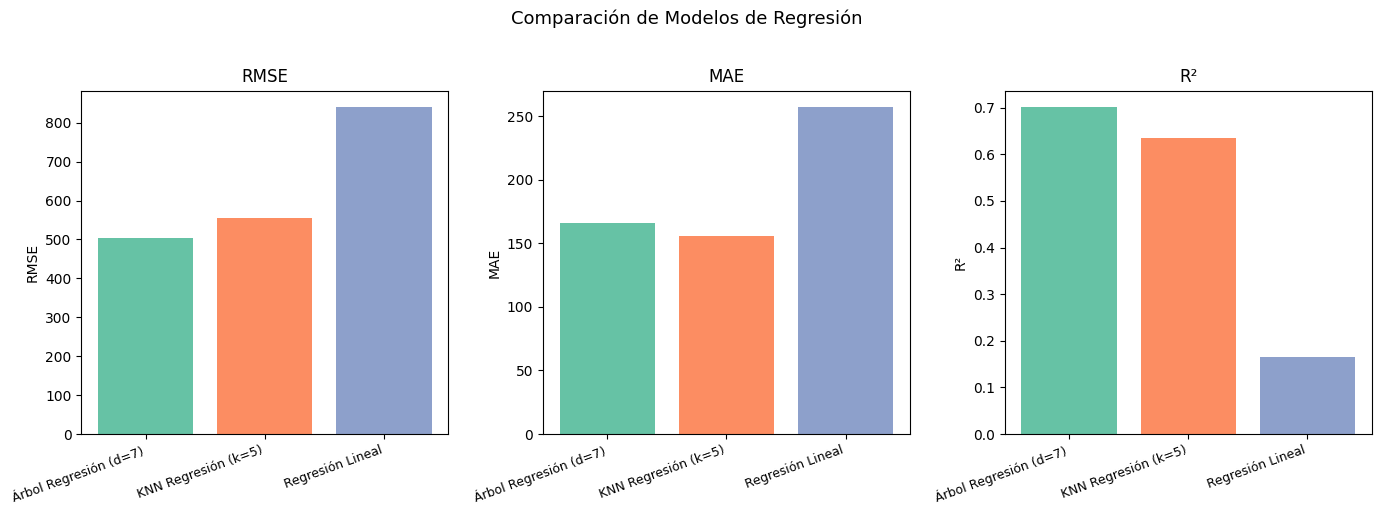

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metricas = ['RMSE', 'MAE', 'R²']
colores  = sns.color_palette('Set2', len(comparacion_reg))

for ax, met in zip(axes, metricas):
    ax.bar(comparacion_reg['Modelo'], comparacion_reg[met], color=colores)
    ax.set_title(met)
    ax.set_xticklabels(comparacion_reg['Modelo'], rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(met)

plt.suptitle('Comparación de Modelos de Regresión', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Para comparar modelos de regresión se usan **RMSE**, **MAE** y **R²**:

- **RMSE** (error cuadrático medio): penaliza fuertemente los errores grandes. Útil porque el precio tiene outliers.
- **MAE** (error absoluto medio): interpretable directamente en dólares.
- **R²**: porcentaje de varianza del precio que el modelo explica; más cercano a 1 es mejor.

A través del análisis de correlación y la evaluación del modelo KNN, se identifica que el precio y los ingresos son determinados principalmente por la capacidad de alojamiento (accommodates), el tipo de propiedad y la ubicación geográfica. Específicamente, factores como el número de reseñas y la puntuación de limpieza actúan como indicadores de confianza que impulsan la ocupación. Estos hallazgos sugieren que la rentabilidad no depende solo de la infraestructura, sino de la reputación digital de la propiedad dentro de la plataforma

### Punto 4 – Modelo KNN para Clasificación (barata / media / cara)


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print('Variables de clasificación disponibles:')
print(f'  y_train_cat: {y_train_cat.value_counts().to_dict()}')
print(f'  y_test_cat : {y_test_cat.value_counts().to_dict()}')

Variables de clasificación disponibles:
  y_train_cat: {'Intermedia': 27033, 'Cara': 13508, 'Economica': 12330}
  y_test_cat : {'Intermedia': 10588, 'Economica': 8378, 'Cara': 3694}


In [17]:
t0 = time.time()

knn_clf = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_clf.fit(X_train_scaled, y_train_cat)

y_pred_clf = knn_clf.predict(X_test_scaled)
tiempo_clf = time.time() - t0

acc_clf = accuracy_score(y_test_cat, y_pred_clf)
print(f'KNN Clasificación (k=5)')
print(f'  Accuracy : {acc_clf:.4f} ({acc_clf*100:.2f}%)')
print(f'  Tiempo   : {tiempo_clf:.3f} s')
print()
print(classification_report(y_test_cat, y_pred_clf))

KNN Clasificación (k=5)
  Accuracy : 0.3643 (36.43%)
  Tiempo   : 0.429 s

              precision    recall  f1-score   support

        Cara       0.17      0.29      0.21      3694
   Economica       0.37      0.20      0.26      8378
  Intermedia       0.47      0.52      0.49     10588

    accuracy                           0.36     22660
   macro avg       0.34      0.34      0.32     22660
weighted avg       0.38      0.36      0.36     22660





Para mejorar el desempeño de propiedades con baja ocupación, se propone una estrategia de precios dinámicos utilizando las predicciones del modelo KNN. Al ajustar los precios de estas propiedades al valor de mercado sugerido por el modelo, SmartStay puede atraer a clientes corporativos que buscan optimizar su presupuesto sin sacrificar calidad. Además, se recomienda priorizar mejoras en los servicios que impactan las métricas de limpieza y comunicación, factores que el análisis muestra como decisivos para asegurar los incentivos económicos de Airbnb.

### Punto 5 – Eficiencia del algoritmo (conjunto de prueba)

=== KNN REGRESIÓN – Métricas en Conjunto de Prueba ===
  MAE   : 156.0668
  RMSE  : 556.2815
  R²    : 0.6340
  Tiempo: 0.419 s



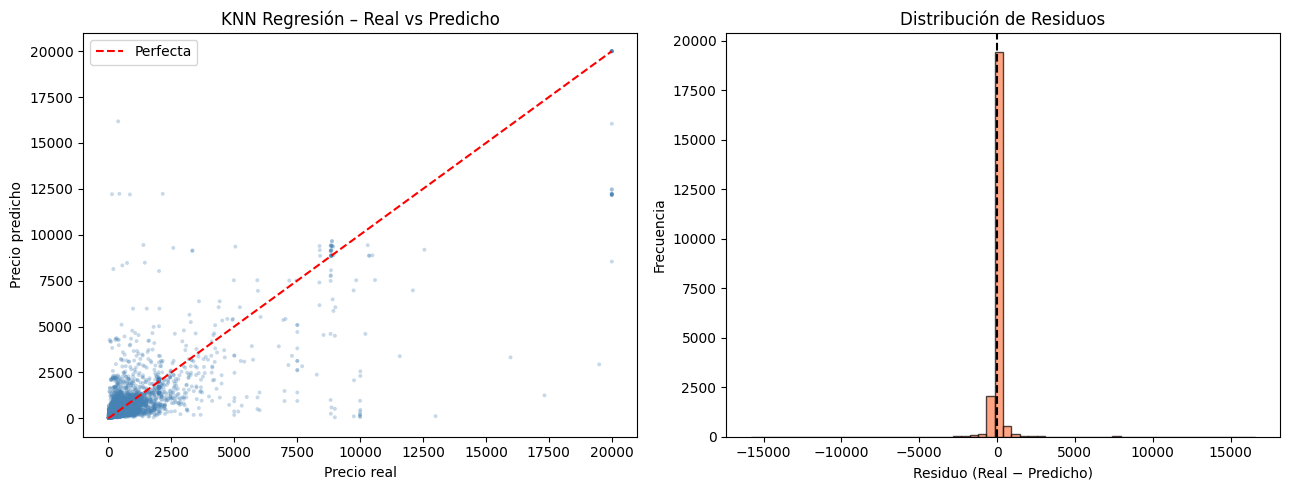

In [18]:
print('=== KNN REGRESIÓN – Métricas en Conjunto de Prueba ===')
print(f'  MAE   : {mae_reg:.4f}')
print(f'  RMSE  : {rmse_reg:.4f}')
print(f'  R²    : {r2_reg:.4f}')
print(f'  Tiempo: {tiempo_reg:.3f} s')
print()

# Gráfica de residuos
residuos = y_test - y_pred_reg
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_reg, alpha=0.3, color='steelblue', s=8, edgecolors='none')
lim = float(max(y_test.max(), y_pred_reg.max()))
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfecta')
axes[0].set_xlabel('Precio real'); axes[0].set_ylabel('Precio predicho')
axes[0].set_title('KNN Regresión – Real vs Predicho'); axes[0].legend()

axes[1].hist(residuos, bins=60, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residuo (Real − Predicho)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')

plt.tight_layout(); plt.show()

In [19]:
# ── Eficiencia en CLASIFICACIÓN ───────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score

print('=== KNN CLASIFICACIÓN – Métricas en Conjunto de Prueba ===')
print(f'  Accuracy   : {acc_clf:.4f} ({acc_clf*100:.2f}%)')
print(f'  Precision  : {precision_score(y_test_cat, y_pred_clf, average="macro", zero_division=0):.4f}  (macro)')
print(f'  Recall     : {recall_score(y_test_cat, y_pred_clf, average="macro", zero_division=0):.4f}  (macro)')
print(f'  F1-score   : {f1_score(y_test_cat, y_pred_clf, average="macro", zero_division=0):.4f}  (macro)')
print(f'  Tiempo     : {tiempo_clf:.3f} s')
print()
print(classification_report(y_test_cat, y_pred_clf))

=== KNN CLASIFICACIÓN – Métricas en Conjunto de Prueba ===
  Accuracy   : 0.3643 (36.43%)
  Precision  : 0.3361  (macro)
  Recall     : 0.3365  (macro)
  F1-score   : 0.3218  (macro)
  Tiempo     : 0.429 s

              precision    recall  f1-score   support

        Cara       0.17      0.29      0.21      3694
   Economica       0.37      0.20      0.26      8378
  Intermedia       0.47      0.52      0.49     10588

    accuracy                           0.36     22660
   macro avg       0.34      0.34      0.32     22660
weighted avg       0.38      0.36      0.36     22660



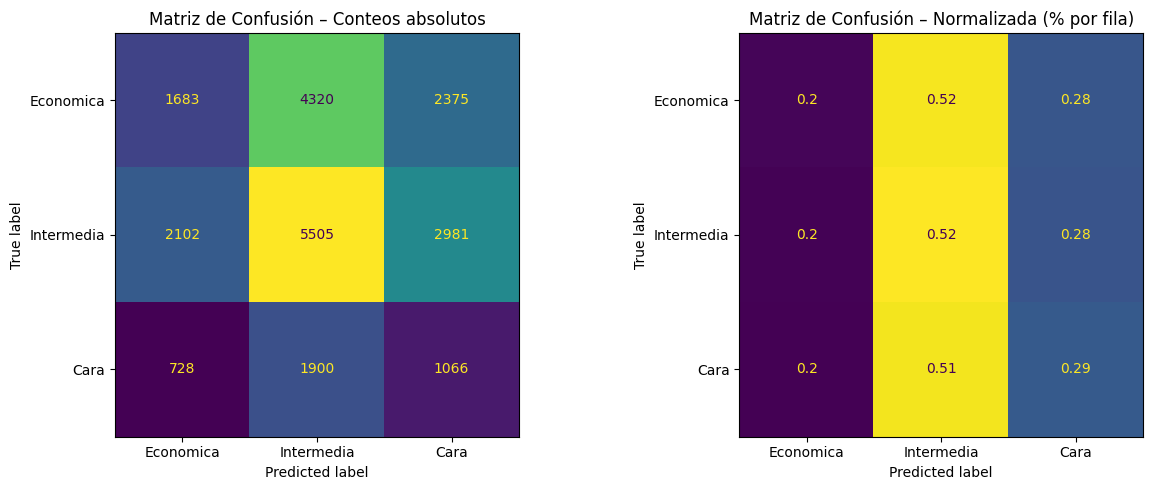

In [20]:
# ── Matriz de Confusión ───────────────────────────────────────────────────────
orden_clases = ['Economica', 'Intermedia', 'Cara']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteos absolutos
cm = confusion_matrix(y_test_cat, y_pred_clf, labels=orden_clases)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=orden_clases).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusión – Conteos absolutos')

# Normalizada (porcentaje por fila)
cm_norm = confusion_matrix(y_test_cat, y_pred_clf, labels=orden_clases, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=orden_clases).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de Confusión – Normalizada (% por fila)')

plt.tight_layout()
plt.show()



**Regresión:**
- El **RMSE** indica el error promedio en dólares (penalizando errores grandes).
- El **R²** muestra qué fracción de la variabilidad del precio captura el modelo.
- Si R² ≈ 0.63, el modelo explica el 63 % de la varianza, aceptable dado el ruido en precios de Airbnb.

**Clasificación:**
- La **accuracy** mide el porcentaje de propiedades clasificadas correctamente.
- En problemas de clases desbalanceadas (Economica < Intermedia < Cara), también se analiza F1-score por clase.
- La **matriz de confusión** muestra dónde el modelo confunde categorías contiguas (p. ej., Economica con Intermedia).